In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import optax
import matplotlib.pyplot as plt
from functools import partial
import time
import requests
import io

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

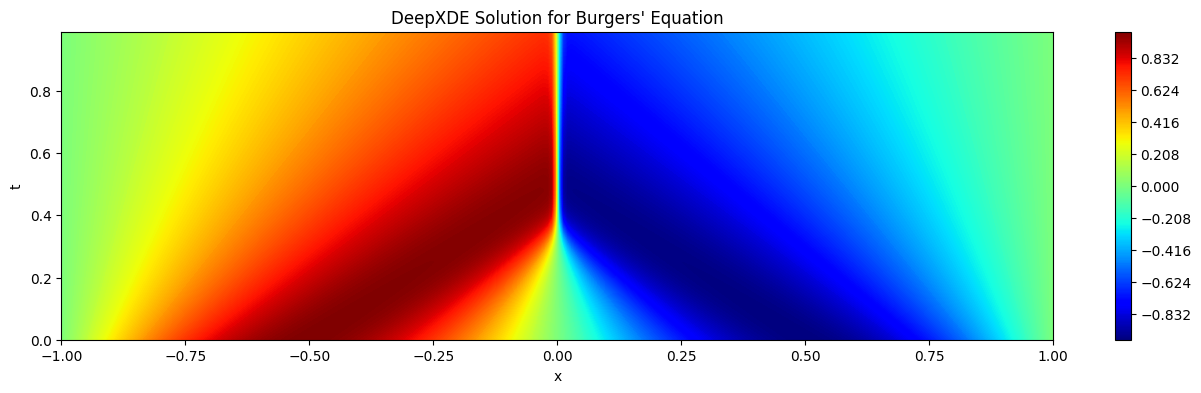

In [2]:
# DeepXDE reference data
url = 'https://github.com/lululxvi/deepxde/raw/master/examples/dataset/Burgers.npz'
response = requests.get(url)
response.raise_for_status()

data = np.load(io.BytesIO(response.content))
t_ref, x_ref, exact = data['t'], data['x'], data['usol'].T
x_ref, t_ref = np.meshgrid(x_ref, t_ref)

plt.figure(figsize=(16, 4))
plt.contourf(x_ref, t_ref, exact, levels=250, cmap='jet')
plt.colorbar()
plt.xlabel('x')
plt.ylabel('t')
plt.title("DeepXDE Solution for Burgers' Equation")
plt.show()

In [3]:
class FCN:
    @staticmethod
    def init_parameters(key, layer_sizes):
        keys = jax.random.split(key, len(layer_sizes) - 1)

        parameters = []

        for k, n_in, n_out in zip(keys, layer_sizes[:-1], layer_sizes[1:]):
            W_key, b_key = jax.random.split(k)

            scale = jnp.sqrt(2.0 / (n_in + n_out))
            W = jax.random.uniform(W_key, (n_out, n_in), minval=-scale, maxval=scale)
            b = jnp.zeros(n_out)

            parameters.append((W, b))

        return parameters

    @staticmethod
    def forward(parameters, x):
        activation = jnp.tanh

        # Iterate over all layers except the last one
        for W, b in parameters[:-1]:
            x = jnp.dot(W, x) + b
            x = activation(x)

        # Last layer (No activation)
        W_out, b_out = parameters[-1]
        x = jnp.dot(W_out, x) + b_out

        return x[0] # Return scalar


from jax import grad, vmap

def u_net(parameters, x, t):
    # Stack scalar x and t to create input vector [x, t]
    inputs = jnp.stack([x, t])
    return FCN.forward(parameters, inputs)

def pde_residual_single(parameters, x, t, nu=0.01):
    u = u_net(parameters, x, t)
    u_t = grad(u_net, argnums=2)(parameters, x, t)
    u_x = grad(u_net, argnums=1)(parameters, x, t)
    u_xx = grad(grad(u_net, argnums=1), argnums=1)(parameters, x, t)

    # Burgers' Equation
    residual = u_t + u * u_x - (nu / jnp.pi) * u_xx
    return residual

pde_residual = vmap(pde_residual_single, in_axes=(None, 0, 0))

def initial_condition(x):
    return -jnp.sin(jnp.pi * x)

def boundary_condition(t):
    return jnp.zeros_like(t)


In [4]:
# Shared training / evaluation grids
x = jnp.linspace(-1, 1, 200)
t = jnp.linspace(0, 1, 100)

x_train, t_train = jnp.meshgrid(x, t)
x_train = x_train.flatten()
t_train = t_train.flatten()

# PINN / FFPINN data
x_col_pinn = x_train.flatten()
t_col_pinn = t_train.flatten()

x_ic = jnp.array(x.flatten())
t_ic = jnp.zeros_like(x_ic)
u_ic_true_pinn = initial_condition(x_ic)

t_bc = jnp.array(t.flatten())
x_left = jnp.full_like(t_bc, -1.0)
x_right = jnp.full_like(t_bc, 1.0)
bc_target_pinn = boundary_condition(t_bc)

# FBPINN / FFFBPINN data
x_mesh, t_mesh = jnp.meshgrid(x, t)
x_col = x_mesh.flatten()
t_col = t_mesh.flatten()
batch_col = jnp.stack([x_col, t_col], axis=1)

x_ic_flat = x
t_ic_flat = jnp.zeros_like(x_ic_flat)
batch_ic = jnp.stack([x_ic_flat, t_ic_flat], axis=1)
u_ic_true = -jnp.sin(jnp.pi * x_ic_flat)

t_bc_flat = t
x_left_bc = jnp.full_like(t_bc_flat, -1.0)
batch_bc_left = jnp.stack([x_left_bc, t_bc_flat], axis=1)
x_right_bc = jnp.full_like(t_bc_flat, 1.0)
batch_bc_right = jnp.stack([x_right_bc, t_bc_flat], axis=1)
batch_bc = jnp.concatenate([batch_bc_left, batch_bc_right], axis=0)
bc_target = jnp.zeros(batch_bc.shape[0])

# Evaluation grid
x_eval = jnp.linspace(-1, 1, 100)
t_eval = jnp.linspace(0, 1, 100)
x_eval_mesh, t_eval_mesh = jnp.meshgrid(x_eval, t_eval)
eval_input = jnp.stack([x_eval_mesh.flatten(), t_eval_mesh.flatten()], axis=1)


In [5]:
layer_sizes = [2] + [20]*6 + [1]

pinn_key = jax.random.PRNGKey(1)
pinn_params = FCN.init_parameters(pinn_key, layer_sizes)

pinn_optimizer = optax.adam(learning_rate=0.001)
pinn_opt_state = pinn_optimizer.init(pinn_params)

def loss_fn(params, x_ic, t_ic, u_ic_true, x_left, x_right, t_bc, bc_target, x_col, t_col):

    # IC Loss
    ic_input = jnp.stack([x_ic, t_ic], axis=1)
    u_pred_ic = jax.vmap(FCN.forward, (None, 0))(params, ic_input)
    loss_ic = jnp.mean((u_pred_ic - u_ic_true)**2)

    # BC Loss
    bc_left_in = jnp.stack([x_left, t_bc], axis=1)
    bc_right_in = jnp.stack([x_right, t_bc], axis=1)

    u_pred_left = jax.vmap(FCN.forward, (None, 0))(params, bc_left_in)
    u_pred_right = jax.vmap(FCN.forward, (None, 0))(params, bc_right_in)

    loss_bc = jnp.mean((u_pred_left - bc_target)**2) + \
              jnp.mean((u_pred_right - bc_target)**2)

    # PDE Residual Loss
    residual = pde_residual(params, x_col, t_col)
    loss_pde = jnp.mean(residual**2)
    return loss_ic + loss_bc + loss_pde

@jax.jit
def pinn_update_step(params, opt_state, x_ic, t_ic, u_ic_true, x_left, x_right, t_bc, bc_target, x_col, t_col):
    loss, grads = jax.value_and_grad(loss_fn)(
        params, x_ic, t_ic, u_ic_true, x_left, x_right, t_bc, bc_target, x_col, t_col
    )

    updates, opt_state = pinn_optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)

    return params, opt_state, loss


In [6]:
print("Starting Training with standard PINNs...")
start_time = time.time()

num_epochs = 1000
pinn_losses = []

for epoch in range(num_epochs):
    pinn_params, pinn_opt_state, pinn_loss_val = pinn_update_step(
        pinn_params, pinn_opt_state,
        x_ic, t_ic, u_ic_true_pinn,
        x_left, x_right, t_bc, bc_target_pinn,
        x_col_pinn, t_col_pinn
    )

    pinn_losses.append(float(pinn_loss_val))

    if (epoch + 1) % 500 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], loss: {pinn_loss_val:.6f}")

pinn_time = time.time() - start_time

print(f"Training Time: {pinn_time:.2f}s")

Starting Training with standard PINNs...
Epoch [500/1000], loss: 0.156516
Epoch [1000/1000], loss: 0.152377
Training Time: 13.08s


In [7]:
# FFPINN = standard PINN with the same x-only Fourier feature configuration
# used in the final FFFBPINN architecture, but without domain decomposition.

class FFPINN:
    @staticmethod
    def fourier_x_features(x, t, Bx):
        proj = 2.0 * jnp.pi * (Bx * x)
        return jnp.concatenate([
            jnp.array([x, t]),
            jnp.sin(proj),
            jnp.cos(proj)
        ])

    @staticmethod
    def forward(parameters, inputs, Bx):
        x, t = inputs[0], inputs[1]
        net_in = FFPINN.fourier_x_features(x, t, Bx)
        return FCN.forward(parameters, net_in)


def ffpinn_pde_residual_single(parameters, x, t, Bx, nu=0.01):
    def u_fn(x_val, t_val):
        return FFPINN.forward(parameters, jnp.stack([x_val, t_val]), Bx)

    u = u_fn(x, t)
    u_t = grad(u_fn, argnums=1)(x, t)
    u_x = grad(u_fn, argnums=0)(x, t)
    u_xx = grad(grad(u_fn, argnums=0), argnums=0)(x, t)
    residual = u_t + u * u_x - (nu / jnp.pi) * u_xx
    return residual


ffpinn_pde_residual = vmap(ffpinn_pde_residual_single, in_axes=(None, 0, 0, None))


In [8]:
# Match the Fourier-feature configuration used in the final FFFBPINN architecture
m = 8
sigma = 2.0
Bx_key = jax.random.PRNGKey(1234)
Bx = jax.random.normal(Bx_key, (m,)) * sigma

input_dim = 2 + 2 * m
ffpinn_layer_sizes = [input_dim] + [20] * 6 + [1]

ffpinn_key = jax.random.PRNGKey(1)
ffpinn_params = FCN.init_parameters(ffpinn_key, ffpinn_layer_sizes)

ffpinn_optimizer = optax.adam(learning_rate=0.001)
ffpinn_opt_state = ffpinn_optimizer.init(ffpinn_params)


def ffpinn_loss_fn(params, x_ic, t_ic, u_ic_true, x_left, x_right, t_bc, bc_target, x_col, t_col, Bx):
    ic_input = jnp.stack([x_ic, t_ic], axis=1)
    u_pred_ic = jax.vmap(FFPINN.forward, (None, 0, None))(params, ic_input, Bx)
    loss_ic = jnp.mean((u_pred_ic - u_ic_true) ** 2)

    bc_left_in = jnp.stack([x_left, t_bc], axis=1)
    bc_right_in = jnp.stack([x_right, t_bc], axis=1)

    u_pred_left = jax.vmap(FFPINN.forward, (None, 0, None))(params, bc_left_in, Bx)
    u_pred_right = jax.vmap(FFPINN.forward, (None, 0, None))(params, bc_right_in, Bx)

    loss_bc = jnp.mean((u_pred_left - bc_target) ** 2) +               jnp.mean((u_pred_right - bc_target) ** 2)

    residual = ffpinn_pde_residual(params, x_col, t_col, Bx)
    loss_pde = jnp.mean(residual ** 2)
    return loss_ic + loss_bc + loss_pde


@jax.jit
def ffpinn_update_step(params, opt_state, x_ic, t_ic, u_ic_true, x_left, x_right, t_bc, bc_target, x_col, t_col, Bx):
    loss, grads = jax.value_and_grad(ffpinn_loss_fn)(
        params, x_ic, t_ic, u_ic_true, x_left, x_right, t_bc, bc_target, x_col, t_col, Bx
    )

    updates, opt_state = ffpinn_optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)

    return params, opt_state, loss


print("Starting Training with Fourier-feature PINNs...")
start_time = time.time()
num_epochs = 1000
ffpinn_losses = []

for epoch in range(num_epochs):
    ffpinn_params, ffpinn_opt_state, ffpinn_loss_val = ffpinn_update_step(
        ffpinn_params, ffpinn_opt_state,
        x_ic, t_ic, u_ic_true_pinn,
        x_left, x_right, t_bc, bc_target_pinn,
        x_col_pinn, t_col_pinn,
        Bx
    )

    ffpinn_losses.append(float(pinn_loss_val))

    if (epoch + 1) % 500 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], loss: {ffpinn_loss_val:.6f}")

ffpinn_time = time.time() - start_time
print(f"Training Time: {ffpinn_time:.2f}s")


Starting Training with Fourier-feature PINNs...
Epoch [500/1000], loss: 0.084600
Epoch [1000/1000], loss: 0.055254
Training Time: 12.19s


In [9]:
class FBCN:
    @staticmethod
    def init_parameters(key, layer_sizes):
        keys = jax.random.split(key, len(layer_sizes) - 1)
        parameters = [FBCN._random_layer_parameters(k, m, n)
                      for k, m, n in zip(keys, layer_sizes[:-1], layer_sizes[1:])]
        return parameters

    @staticmethod
    def _random_layer_parameters(key, m, n):
        W_key, b_key = jax.random.split(key)
        scale = jnp.sqrt(2.0 / (m + n))
        W = jax.random.uniform(W_key, (n, m), minval=-scale, maxval=scale)
        b = jnp.zeros(n)
        return W, b

    @staticmethod
    def forward(parameters, x):
        activation_fn = jnp.tanh
        for W, b in parameters[:-1]:
            x = jnp.dot(W, x) + b
            x = activation_fn(x)
        W_out, b_out = parameters[-1]
        u = jnp.dot(W_out, x) + b_out
        return u[0]

class FBPINN:
    @staticmethod
    def init_parameters(key, layer_sizes, J):
        keys = jax.random.split(key, J)
        parameters = jax.vmap(FBCN.init_parameters, in_axes=(0, None))(keys, layer_sizes)
        return parameters

    @staticmethod
    def get_subdomain_tranges(J, width):
        min_width = 1.0 / (J - 1) if J > 1 else 1.0
        assert width >= min_width * 0.99, f"Width too small"

        if J == 1:
            t_centers = jnp.array([0.5])
        else:
            t_centers = jnp.linspace(0, 1, J)

        tmins = t_centers - width/2
        tmaxs = t_centers + width/2
        tranges = jnp.stack([tmins, tmaxs], axis=1)
        return tranges

    @staticmethod
    def window(trange, t):
        tmin, tmax = trange
        mu, sd = (tmin + tmax) / 2, (tmax - tmin) / 2
        t_local = (t - mu) / sd
        w = ((1 + jnp.cos(jnp.pi * t_local)) / 2)**2
        w = jnp.heaviside(t - tmin, 1.0) * jnp.heaviside(tmax - t, 1.0) * w
        return w

    @staticmethod
    def forward_single_subdomain(params_j, trange_j, inputs):
        x, t = inputs[0], inputs[1]
        tmin, tmax = trange_j
        mu, sd = (tmin + tmax) / 2, (tmax - tmin) / 2

        t_norm = (t - mu) / sd
        net_in = jnp.stack([x, t_norm])

        u_net = FBCN.forward(params_j, net_in)
        w_val = FBPINN.window(trange_j, t)
        return u_net * w_val, w_val

    @staticmethod
    def forward(parameters, tranges, inputs):
        us, ws = jax.vmap(FBPINN.forward_single_subdomain, in_axes=(0, 0, None))(
            parameters, tranges, inputs
        )
        epsilon = 1e-8
        u_global = jnp.sum(us) / (jnp.sum(ws) + epsilon)
        return u_global

def FBPINN_physics_loss(parameters, tranges, inputs, network, nu=0.01/jnp.pi):
    def u_fn(in_vec):
        return network.forward(parameters, tranges, in_vec).squeeze()

    grad_u = jax.grad(u_fn)(inputs)
    u_x = grad_u[0]
    u_t = grad_u[1]

    def u_x_fn(in_vec):
        return jax.grad(u_fn)(in_vec)[0]

    u_xx = jax.grad(u_x_fn)(inputs)[0]
    u = u_fn(inputs)

    residual = u_t + u * u_x - nu * u_xx
    return residual**2

def FBPINN_ic_loss(parameters, tranges, inputs, network, u_target):
    u_pred = network.forward(parameters, tranges, inputs).squeeze()
    return (u_pred - u_target)**2

def FBPINN_bc_loss(parameters, tranges, inputs, network, u_target):
    u_pred = network.forward(parameters, tranges, inputs).squeeze()
    return (u_pred - u_target)**2

def FBPINN_loss_batch(parameters, tranges, batch_col, batch_ic, batch_bc, u_ic_true, bc_target, network):
    losses_physics = jax.vmap(FBPINN_physics_loss, in_axes=(None, None, 0, None))(
        parameters, tranges, batch_col, network
    )
    loss_pde = jnp.mean(losses_physics)

    losses_ic = jax.vmap(FBPINN_ic_loss, in_axes=(None, None, 0, None, 0))(
        parameters, tranges, batch_ic, network, u_ic_true
    )
    loss_ic = jnp.mean(losses_ic)

    losses_bc = jax.vmap(FBPINN_bc_loss, in_axes=(None, None, 0, None, 0))(
        parameters, tranges, batch_bc, network, bc_target
    )
    loss_bc = jnp.mean(losses_bc)

    return loss_pde + 10.0*loss_ic + 10.0*loss_bc


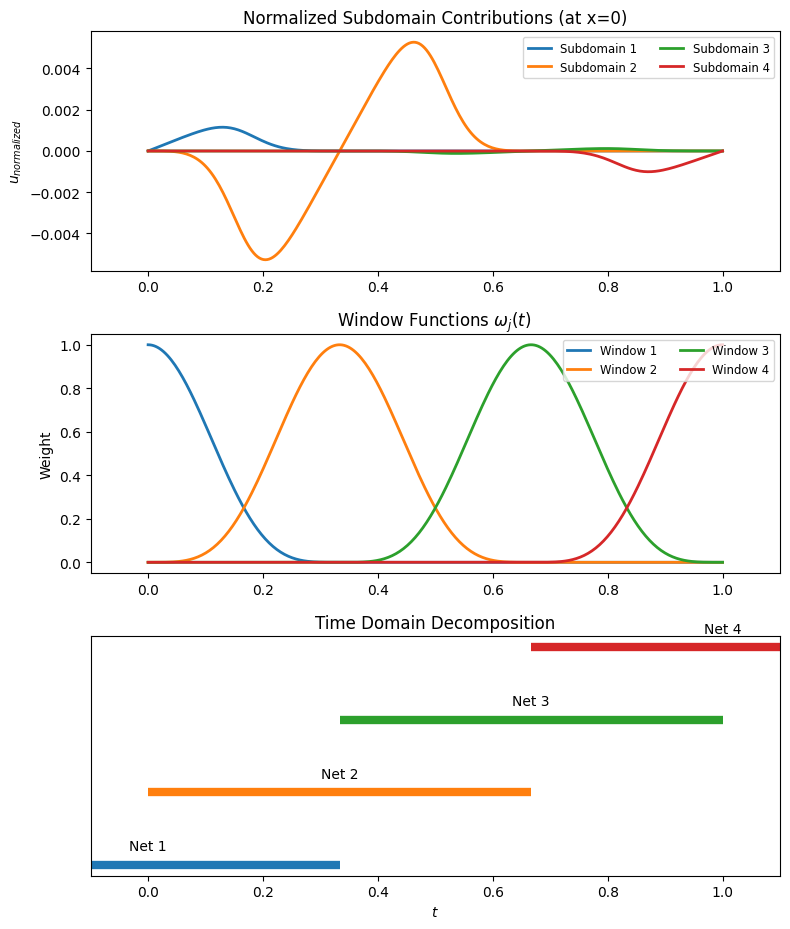

In [10]:
fbpinn_key = jax.random.PRNGKey(1)
fbpinn_optimizer = optax.adam(learning_rate=0.001)

J = 4
width = 2.0 / (J - 1)
subdomain_layers = [2, 20, 20, 20, 20, 20, 20, 1]

fbpinn_parameters = FBPINN.init_parameters(fbpinn_key, subdomain_layers, J)
fbpinn_tranges = FBPINN.get_subdomain_tranges(J, width)
fbpinn_opt_state = fbpinn_optimizer.init(fbpinn_parameters)

t_test_sub = jnp.linspace(0, 1, 300)
x_fixed = jnp.zeros_like(t_test_sub)
test_inputs = jnp.stack([x_fixed, t_test_sub], axis=1)

us, ws = jax.vmap(
    jax.vmap(FBPINN.forward_single_subdomain, in_axes=(None, None, 0)),
    in_axes=(0, 0, None)
)(fbpinn_parameters, fbpinn_tranges, test_inputs)

us = us.squeeze()
ws = ws.squeeze()

us_normalized = us / (ws.sum(axis=0, keepdims=True) + 1e-8)
ws_normalized = ws / (ws.sum(axis=0, keepdims=True) + 1e-8)

plt.figure(figsize=(8, 9.4))
plt.subplot(3, 1, 1)
for j in range(J):
    plt.plot(t_test_sub, us_normalized[j], label=f"Subdomain {j+1}", lw=2)
plt.title("Normalized Subdomain Contributions (at x=0)")
plt.ylabel("$u_{normalized}$")
plt.legend(loc="upper right", fontsize='small', ncol=2)
plt.xlim(-0.1, 1.1)

plt.subplot(3, 1, 2)
for j in range(J):
    plt.plot(t_test_sub, ws[j], label=f"Window {j+1}", lw=2)
plt.title(r"Window Functions $\omega_j(t)$ ")
plt.ylabel("Weight")
plt.legend(loc="upper right", fontsize='small', ncol=2)
plt.xlim(-0.1, 1.1)

plt.subplot(3, 1, 3)
for j in range(J):
    t_start, t_end = fbpinn_tranges[j]
    plt.hlines(j % J, t_start, t_end, linewidth=6, color=colors[j % len(colors)])
    plt.text((t_start+t_end)/2, j % J + 0.2, f"Net {j+1}", ha='center')

plt.title("Time Domain Decomposition")
plt.xlabel("$t$")
plt.yticks([])
plt.xlim(-0.1, 1.1)

plt.tight_layout()
plt.show()

@partial(jax.jit, static_argnums=(7,))
def fbpinn_train_step(params, opt_state, batch_col, batch_ic, batch_bc, u_ic_true, bc_target, network):
    loss, grads = jax.value_and_grad(FBPINN_loss_batch)(
        params, fbpinn_tranges, batch_col, batch_ic, batch_bc, u_ic_true, bc_target, network
    )

    updates, opt_state = fbpinn_optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)

    return params, opt_state, loss


In [11]:
print(f"Starting Training with {J} subdomains...")
start_time = time.time()
num_epochs = 1000
fbpinn_losses = []

for epoch in range(num_epochs):
    fbpinn_parameters, fbpinn_opt_state, fbpinn_loss_val = fbpinn_train_step(
        fbpinn_parameters, fbpinn_opt_state,
        batch_col, batch_ic, batch_bc,
        u_ic_true, bc_target,
        FBPINN
    )

    fbpinn_losses.append(float(pinn_loss_val))

    if (epoch + 1) % 1000 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {fbpinn_loss_val:.6f}")

fbpinn_time = time.time() - start_time
print(f"Training Time: {fbpinn_time:.2f}s")


Starting Training with 4 subdomains...
Epoch [1000/1000], Loss: 0.239525
Training Time: 51.98s


In [12]:
class FFFBPINN:
    @staticmethod
    def init_parameters(key, layer_sizes, J):
        keys = jax.random.split(key, J)
        parameters = jax.vmap(FBCN.init_parameters, in_axes=(0, None))(keys, layer_sizes)
        return parameters

    @staticmethod
    def get_subdomain_tranges(J, width):
        min_width = 1.0 / (J - 1) if J > 1 else 1.0
        assert width >= min_width * 0.99, f"Width too small"

        if J == 1:
            t_centers = jnp.array([0.5])
        else:
            t_centers = jnp.linspace(0, 1, J)

        tmins = t_centers - width / 2
        tmaxs = t_centers + width / 2
        tranges = jnp.stack([tmins, tmaxs], axis=1)
        return tranges

    @staticmethod
    def window(trange, t):
        tmin, tmax = trange
        mu, sd = (tmin + tmax) / 2, (tmax - tmin) / 2
        t_local = (t - mu) / sd
        w = ((1 + jnp.cos(jnp.pi * t_local)) / 2) ** 2
        w = jnp.heaviside(t - tmin, 1.0) * jnp.heaviside(tmax - t, 1.0) * w
        return w

    @staticmethod
    def fourier_x_features(x, t_norm, Bx):
        # x: scalar
        # Bx: shape (m,)
        proj = 2.0 * jnp.pi * (Bx * x)   # (m,)
        return jnp.concatenate([
            jnp.array([x, t_norm]),
            jnp.sin(proj),
            jnp.cos(proj)
        ])

    @staticmethod
    def forward_single_subdomain(params_j, trange_j, inputs, Bx):
        x, t = inputs[0], inputs[1]
        tmin, tmax = trange_j
        mu, sd = (tmin + tmax) / 2, (tmax - tmin) / 2

        # local time normalization
        t_norm = (t - mu) / sd

        # x-only Fourier embedding
        net_in = FFFBPINN.fourier_x_features(x, t_norm, Bx)

        u_net = FBCN.forward(params_j, net_in)
        w_val = FFFBPINN.window(trange_j, t)
        return u_net * w_val, w_val

    @staticmethod
    def forward(parameters, tranges, inputs, Bx):
        us, ws = jax.vmap(FFFBPINN.forward_single_subdomain, in_axes=(0, 0, None, None))(
            parameters, tranges, inputs, Bx
        )
        epsilon = 1e-8
        u_global = jnp.sum(us) / (jnp.sum(ws) + epsilon)
        return u_global

def FFFBPINN_physics_loss(parameters, tranges, inputs, network, Bx, nu=0.01/jnp.pi):
    def u_fn(in_vec):
        return network.forward(parameters, tranges, in_vec, Bx).squeeze()

    grad_u = jax.grad(u_fn)(inputs)
    u_x = grad_u[0]
    u_t = grad_u[1]

    def u_x_fn(in_vec):
        return jax.grad(u_fn)(in_vec)[0]

    u_xx = jax.grad(u_x_fn)(inputs)[0]
    u = u_fn(inputs)

    residual = u_t + u * u_x - nu * u_xx
    return residual**2


def FFFBPINN_ic_loss(parameters, tranges, inputs, network, Bx, u_target):
    u_pred = network.forward(parameters, tranges, inputs, Bx).squeeze()
    return (u_pred - u_target)**2


def FFFBPINN_bc_loss(parameters, tranges, inputs, network, Bx, u_target):
    u_pred = network.forward(parameters, tranges, inputs, Bx).squeeze()
    return (u_pred - u_target)**2


def FFFBPINN_loss_batch(parameters, tranges, batch_col, batch_ic, batch_bc, u_ic_true, bc_target, network, Bx):
    losses_physics = jax.vmap(FFFBPINN_physics_loss, in_axes=(None, None, 0, None, None))(
        parameters, tranges, batch_col, network, Bx
    )
    loss_pde = jnp.mean(losses_physics)

    losses_ic = jax.vmap(FFFBPINN_ic_loss, in_axes=(None, None, 0, None, None, 0))(
        parameters, tranges, batch_ic, network, Bx, u_ic_true
    )
    loss_ic = jnp.mean(losses_ic)

    losses_bc = jax.vmap(FFFBPINN_bc_loss, in_axes=(None, None, 0, None, None, 0))(
        parameters, tranges, batch_bc, network, Bx, bc_target
    )
    loss_bc = jnp.mean(losses_bc)

    return loss_pde + 10.0 * loss_ic + 10.0 * loss_bc


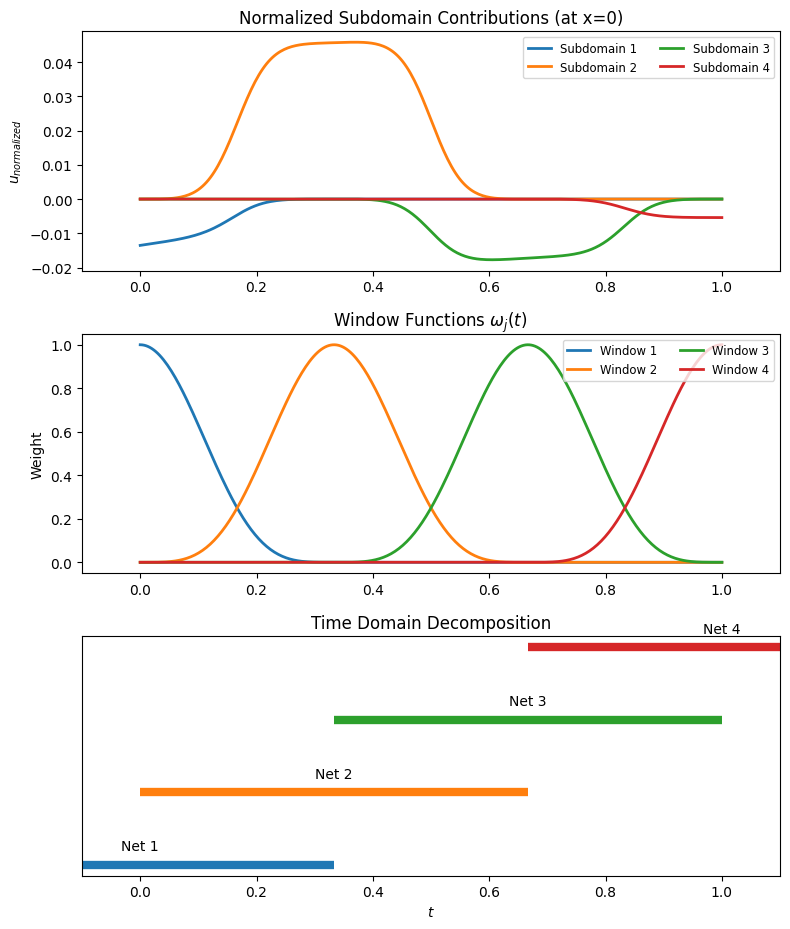

In [13]:
fffbpinn_key = jax.random.PRNGKey(1)
fffbpinn_optimizer = optax.adam(learning_rate=0.001)

J_ff = 4
width_ff = 2.0 / (J_ff - 1)

subdomain_layers_ff = [input_dim, 20, 20, 20, 20, 20, 20, 1]

fffbpinn_parameters = FFFBPINN.init_parameters(fffbpinn_key, subdomain_layers_ff, J_ff)
fffbpinn_tranges = FFFBPINN.get_subdomain_tranges(J_ff, width_ff)
fffbpinn_opt_state = fffbpinn_optimizer.init(fffbpinn_parameters)

t_test_sub = jnp.linspace(0, 1, 300)
x_fixed = jnp.zeros_like(t_test_sub)
test_inputs = jnp.stack([x_fixed, t_test_sub], axis=1)

us_ff, ws_ff = jax.vmap(
    jax.vmap(FFFBPINN.forward_single_subdomain, in_axes=(None, None, 0, None)),
    in_axes=(0, 0, None, None)
)(fffbpinn_parameters, fffbpinn_tranges, test_inputs, Bx)

us_ff = us_ff.squeeze()
ws_ff = ws_ff.squeeze()

us_ff_normalized = us_ff / (ws_ff.sum(axis=0, keepdims=True) + 1e-8)
ws_ff_normalized = ws_ff / (ws_ff.sum(axis=0, keepdims=True) + 1e-8)

plt.figure(figsize=(8, 9.4))
plt.subplot(3, 1, 1)
for j in range(J_ff):
    plt.plot(t_test_sub, us_ff_normalized[j], label=f"Subdomain {j+1}", lw=2)
plt.title("Normalized Subdomain Contributions (at x=0)")
plt.ylabel("$u_{normalized}$")
plt.legend(loc="upper right", fontsize='small', ncol=2)
plt.xlim(-0.1, 1.1)

plt.subplot(3, 1, 2)
for j in range(J_ff):
    plt.plot(t_test_sub, ws_ff[j], label=f"Window {j+1}", lw=2)
plt.title(r"Window Functions $\omega_j(t)$ ")
plt.ylabel("Weight")
plt.legend(loc="upper right", fontsize='small', ncol=2)
plt.xlim(-0.1, 1.1)

plt.subplot(3, 1, 3)
for j in range(J_ff):
    t_start, t_end = fffbpinn_tranges[j]
    plt.hlines(j % J_ff, t_start, t_end, linewidth=6, color=colors[j % len(colors)])
    plt.text((t_start+t_end)/2, j % J_ff + 0.2, f"Net {j+1}", ha='center')

plt.title("Time Domain Decomposition")
plt.xlabel("$t$")
plt.yticks([])
plt.xlim(-0.1, 1.1)

plt.tight_layout()
plt.show()

@partial(jax.jit, static_argnums=(7,))
def fffbpinn_train_step(params, opt_state, batch_col, batch_ic, batch_bc, u_ic_true, bc_target, network, Bx):
    loss, grads = jax.value_and_grad(FFFBPINN_loss_batch)(
        params, fffbpinn_tranges, batch_col, batch_ic, batch_bc, u_ic_true, bc_target, network, Bx
    )

    updates, opt_state = fffbpinn_optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)

    return params, opt_state, loss


In [14]:
print(f"Starting Training with {J_ff} subdomains + x-only Fourier features...")
start_time = time.time()
num_epochs = 1000
fffbpinn_losses = []

for epoch in range(num_epochs):
    fffbpinn_parameters, fffbpinn_opt_state, fffbpinn_loss_val = fffbpinn_train_step(
        fffbpinn_parameters, fffbpinn_opt_state,
        batch_col, batch_ic, batch_bc,
        u_ic_true, bc_target,
        FFFBPINN, Bx
    )

    fffbpinn_losses.append(float(pinn_loss_val))

    if (epoch + 1) % 500 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {fffbpinn_loss_val:.6f}")

fffbpinn_time = time.time() - start_time
print(f"Training Time: {fffbpinn_time:.2f}s")


Starting Training with 4 subdomains + x-only Fourier features...
Epoch [500/1000], Loss: 0.156075
Epoch [1000/1000], Loss: 0.039575
Training Time: 55.58s


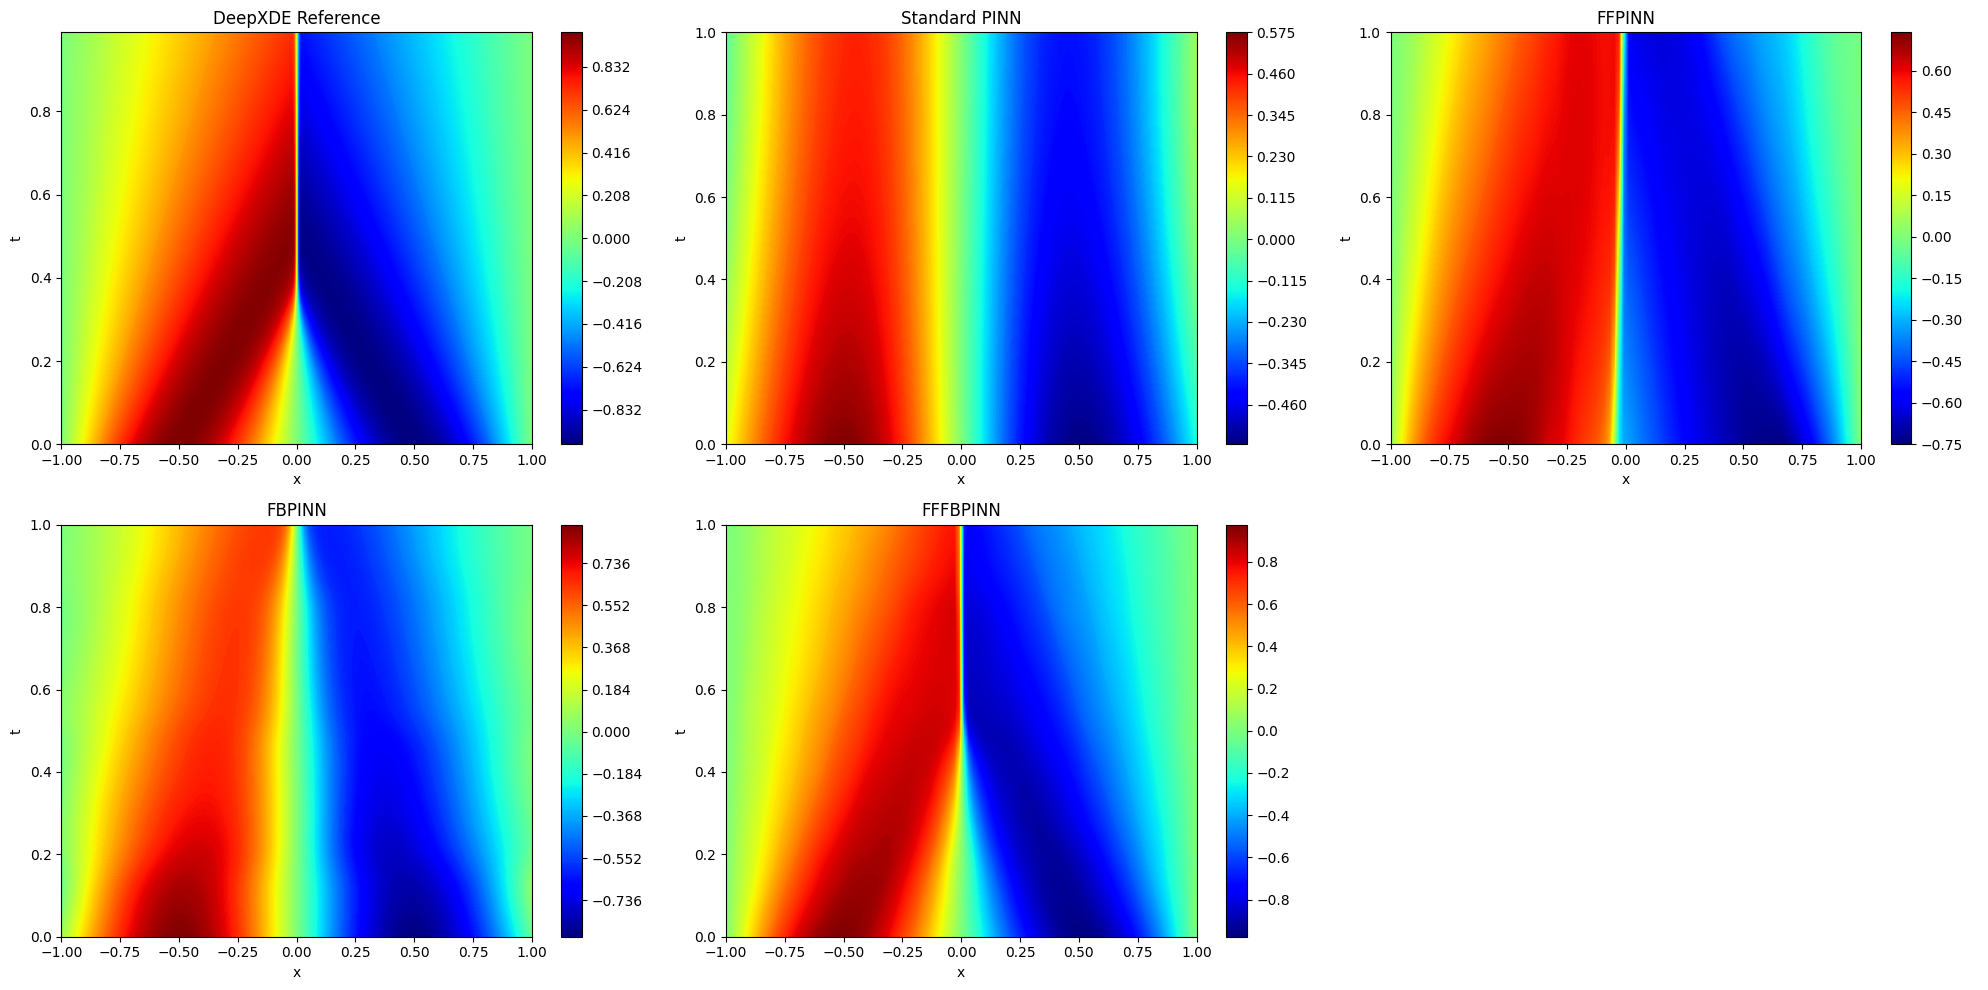

In [15]:
u_pred_pinn = jax.vmap(FCN.forward, (None, 0))(pinn_params, eval_input)
u_plot_pinn = np.array(u_pred_pinn).reshape(100, 100)

u_pred_ffpinn = jax.vmap(FFPINN.forward, (None, 0, None))(ffpinn_params, eval_input, Bx)
u_plot_ffpinn = np.array(u_pred_ffpinn).reshape(100, 100)

u_pred_fbpinn = jax.vmap(FBPINN.forward, (None, None, 0))(fbpinn_parameters, fbpinn_tranges, eval_input)
u_plot_fbpinn = np.array(u_pred_fbpinn).reshape(100, 100)

u_pred_fffbpinn = jax.vmap(FFFBPINN.forward, (None, None, 0, None))(fffbpinn_parameters, fffbpinn_tranges, eval_input, Bx)
u_plot_fffbpinn = np.array(u_pred_fffbpinn).reshape(100, 100)

x_plot = np.array(x_eval_mesh)
t_plot = np.array(t_eval_mesh)

fig, axs = plt.subplots(2, 3, figsize=(20, 10))

cf0 = axs[0, 0].contourf(x_ref, t_ref, exact, levels=250, cmap='jet')
axs[0, 0].set_title('DeepXDE Reference')
axs[0, 0].set_xlabel('x')
axs[0, 0].set_ylabel('t')
plt.colorbar(cf0, ax=axs[0, 0])

cf1 = axs[0, 1].contourf(x_plot, t_plot, u_plot_pinn, levels=250, cmap='jet')
axs[0, 1].set_title('Standard PINN')
axs[0, 1].set_xlabel('x')
axs[0, 1].set_ylabel('t')
plt.colorbar(cf1, ax=axs[0, 1])

cf2 = axs[0, 2].contourf(x_plot, t_plot, u_plot_ffpinn, levels=250, cmap='jet')
axs[0, 2].set_title('FFPINN')
axs[0, 2].set_xlabel('x')
axs[0, 2].set_ylabel('t')
plt.colorbar(cf2, ax=axs[0, 2])

cf3 = axs[1, 0].contourf(x_plot, t_plot, u_plot_fbpinn, levels=250, cmap='jet')
axs[1, 0].set_title('FBPINN')
axs[1, 0].set_xlabel('x')
axs[1, 0].set_ylabel('t')
plt.colorbar(cf3, ax=axs[1, 0])

cf4 = axs[1, 1].contourf(x_plot, t_plot, u_plot_fffbpinn, levels=250, cmap='jet')
axs[1, 1].set_title('FFFBPINN')
axs[1, 1].set_xlabel('x')
axs[1, 1].set_ylabel('t')
plt.colorbar(cf4, ax=axs[1, 1])

axs[1, 2].axis('off')

plt.tight_layout()
plt.show()


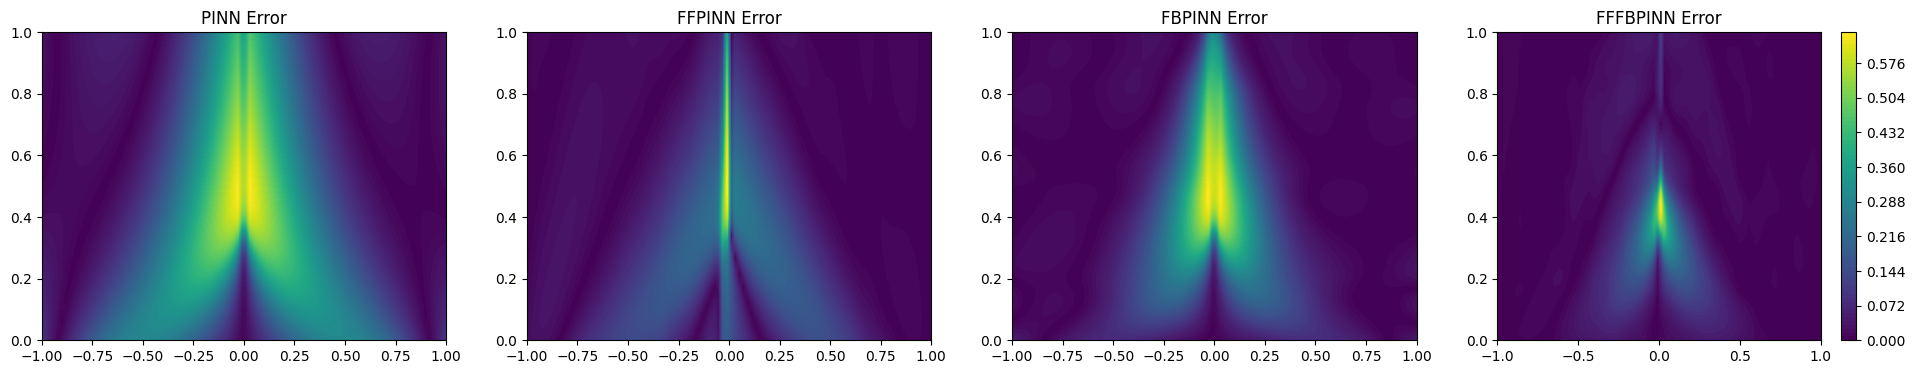

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator

x_plot = np.linspace(-1, 1, 100)
t_plot = np.linspace(0, 1, 100)
X_plot, T_plot = np.meshgrid(x_plot, t_plot)

x_ref_1d = x_ref[0, :] if x_ref.ndim == 2 else x_ref
t_ref_1d = t_ref[:, 0] if t_ref.ndim == 2 else t_ref

interp = RegularGridInterpolator(
    (t_ref_1d, x_ref_1d),
    exact,
    bounds_error=False,
    fill_value=None
)

query = np.column_stack([T_plot.ravel(), X_plot.ravel()])
exact_interp = interp(query).reshape(X_plot.shape)

error_pinn = np.abs(u_plot_pinn - exact_interp)
error_ffpinn = np.abs(u_plot_ffpinn - exact_interp)
error_fbpinn = np.abs(u_plot_fbpinn - exact_interp)
error_fffbpinn = np.abs(u_plot_fffbpinn - exact_interp)

plt.figure(figsize=(24,4))

plt.subplot(1,4,1)
plt.contourf(X_plot, T_plot, error_pinn, levels=100)
plt.title("PINN Error")

plt.subplot(1,4,2)
plt.contourf(X_plot, T_plot, error_ffpinn, levels=100)
plt.title("FFPINN Error")

plt.subplot(1,4,3)
plt.contourf(X_plot, T_plot, error_fbpinn, levels=100)
plt.title("FBPINN Error")

plt.subplot(1,4,4)
plt.contourf(X_plot, T_plot, error_fffbpinn, levels=100)
plt.title("FFFBPINN Error")

plt.colorbar()
plt.show()

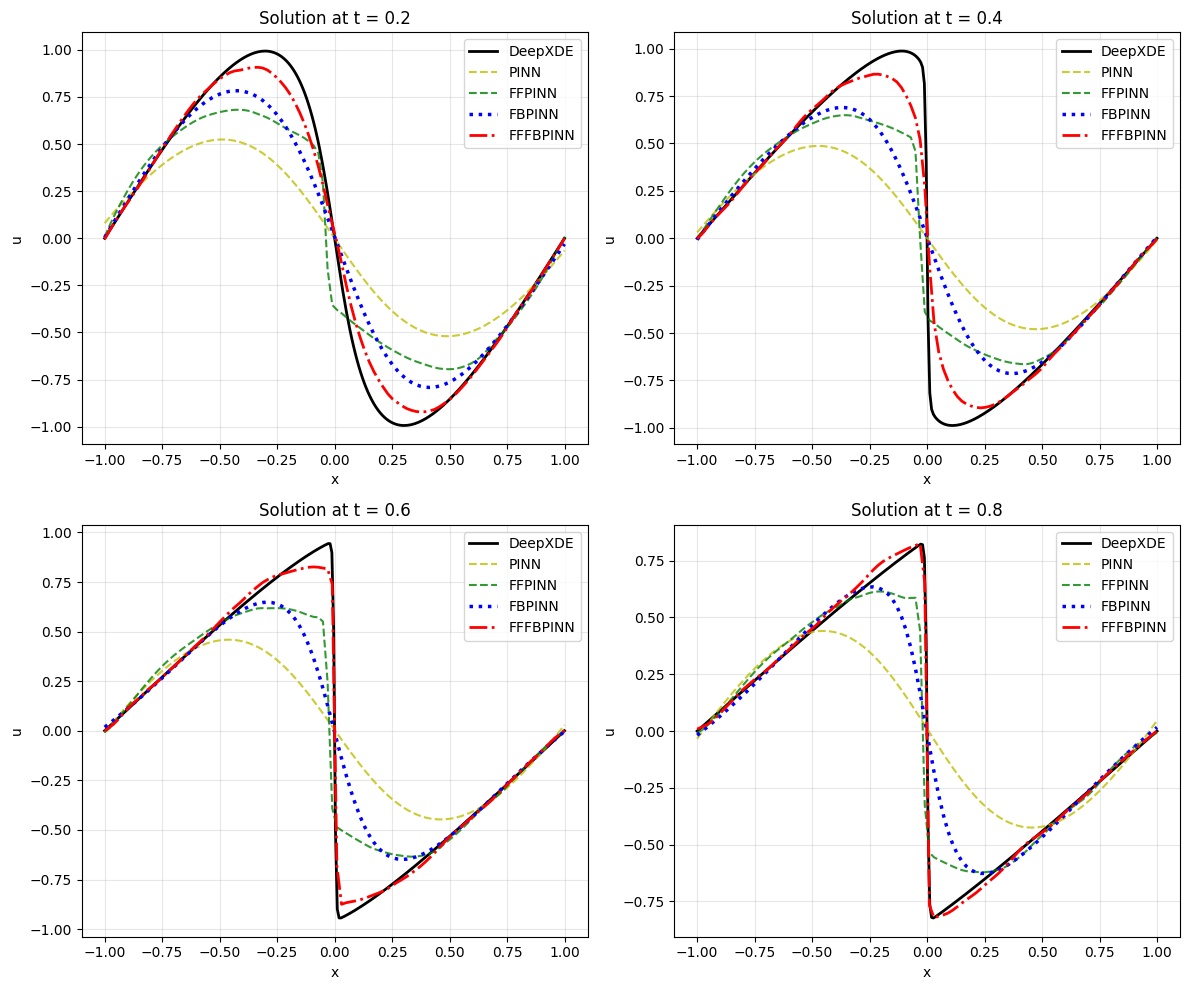

In [19]:
time_slices = [0.2, 0.4, 0.6, 0.8]
num_plots = len(time_slices)
cols = 2
rows = (num_plots // cols) + (num_plots % cols)

fig, axs = plt.subplots(rows, cols, figsize=(12, 5 * rows))
axs = axs.flatten()

for i, t_val in enumerate(time_slices):
    idx_ref = np.argmin(np.abs(t_ref[:, 0] - t_val))
    u_ref_slice = exact[idx_ref, :]

    x_slice = jnp.linspace(-1, 1, 100)
    t_slice = jnp.full_like(x_slice, t_val)
    input_slice = jnp.stack([x_slice, t_slice], axis=1)

    u_pinn_slice = jax.vmap(FCN.forward, (None, 0))(pinn_params, input_slice)
    u_ffpinn_slice = jax.vmap(FFPINN.forward, (None, 0, None))(ffpinn_params, input_slice, Bx)
    u_fbpinn_slice = jax.vmap(FBPINN.forward, (None, None, 0))(fbpinn_parameters, fbpinn_tranges, input_slice)
    u_fffbpinn_slice = jax.vmap(FFFBPINN.forward, (None, None, 0, None))(fffbpinn_parameters, fffbpinn_tranges, input_slice, Bx)

    axs[i].plot(x_ref[0, :], u_ref_slice, 'k-', linewidth=2, label='DeepXDE')
    axs[i].plot(x_slice, u_pinn_slice, 'y--', alpha=0.8, label='PINN')
    axs[i].plot(x_slice, u_ffpinn_slice, 'g--', alpha=0.8, label='FFPINN')
    axs[i].plot(x_slice, u_fbpinn_slice, 'b:', linewidth=2.5, label='FBPINN')
    axs[i].plot(x_slice, u_fffbpinn_slice, 'r-.', linewidth=2.0, label='FFFBPINN')

    axs[i].set_xlabel('x')
    axs[i].set_ylabel('u')
    axs[i].set_title(f'Solution at t = {t_val}')
    axs[i].legend()
    axs[i].grid(True, alpha=0.3)

for j in range(num_plots, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()


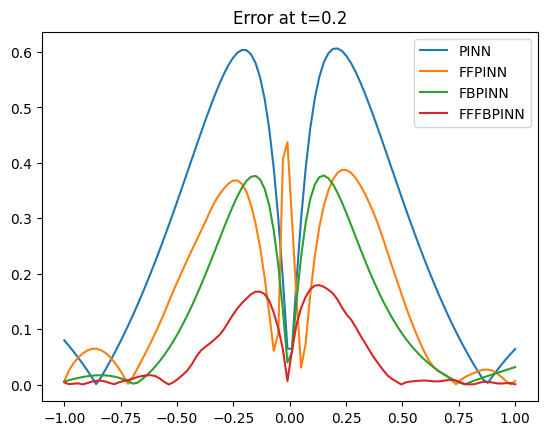

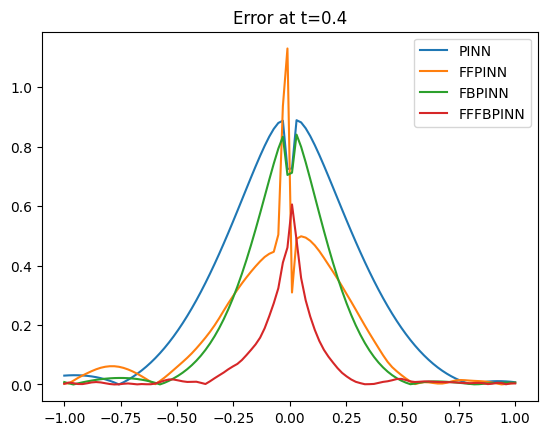

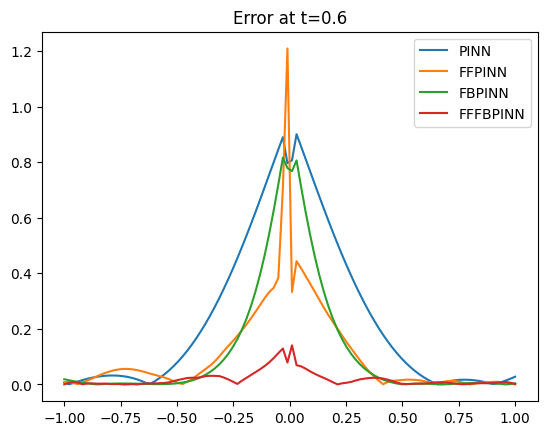

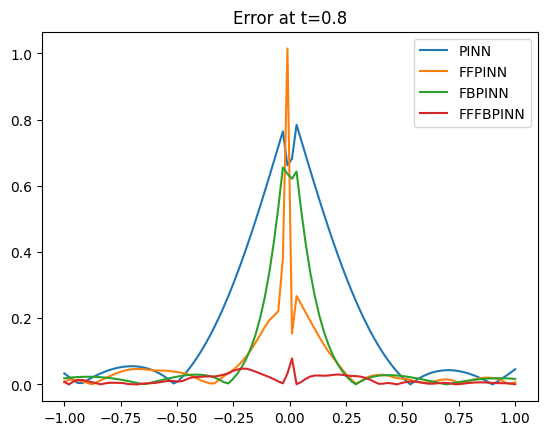

In [20]:
for t_val in time_slices:
    idx = np.argmin(np.abs(t_plot - t_val))

    plt.figure()
    plt.plot(x_plot, np.abs(u_plot_pinn[idx] - exact_interp[idx]), label="PINN")
    plt.plot(x_plot, np.abs(u_plot_ffpinn[idx] - exact_interp[idx]), label="FFPINN")
    plt.plot(x_plot, np.abs(u_plot_fbpinn[idx] - exact_interp[idx]), label="FBPINN")
    plt.plot(x_plot, np.abs(u_plot_fffbpinn[idx] - exact_interp[idx]), label="FFFBPINN")

    plt.title(f"Error at t={t_val}")
    plt.legend()
    plt.show()

Relative L2 error vs DeepXDE
PINN     : 5.663810e-01
FFPINN   : 3.194391e-01
FBPINN   : 3.502054e-01
FFFBPINN : 1.114338e-01


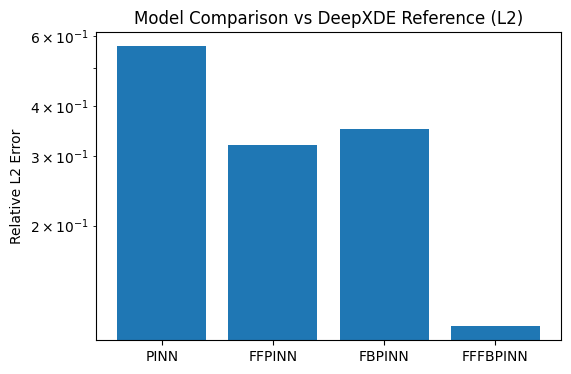

In [21]:
def relative_l2(pred, ref):
    pred = np.asarray(pred, dtype=np.float64)
    ref = np.asarray(ref, dtype=np.float64)
    return np.linalg.norm(pred - ref) / (np.linalg.norm(ref) + 1e-12)

errors = {
    "PINN": relative_l2(u_plot_pinn, exact_interp),
    "FFPINN": relative_l2(u_plot_ffpinn, exact_interp),
    "FBPINN": relative_l2(u_plot_fbpinn, exact_interp),
    "FFFBPINN": relative_l2(u_plot_fffbpinn, exact_interp),
}

print("Relative L2 error vs DeepXDE")
for k, v in errors.items():
    print(f"{k:<9}: {v:.6e}")

plt.figure(figsize=(6, 4))
plt.bar(errors.keys(), errors.values())
plt.ylabel("Relative L2 Error")
plt.title("Model Comparison vs DeepXDE Reference (L2)")
plt.yscale("log")
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.show()

Relative L∞ error vs DeepXDE Reference
PINN     : 9.362139e-01
FFPINN   : 1.242655e+00
FBPINN   : 8.796558e-01
FFFBPINN : 6.387173e-01


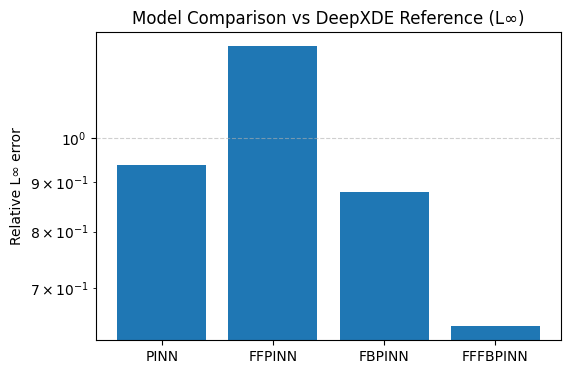

In [22]:
def relative_linf(pred, ref):
    return np.max(np.abs(pred - ref)) / (np.max(np.abs(ref)) + 1e-12)

errors = {
    "PINN": relative_linf(u_plot_pinn, exact_interp),
    "FFPINN": relative_linf(u_plot_ffpinn, exact_interp),
    "FBPINN": relative_linf(u_plot_fbpinn, exact_interp),
    "FFFBPINN": relative_linf(u_plot_fffbpinn, exact_interp),
}

print("Relative L∞ error vs DeepXDE Reference")
for k, v in errors.items():
    print(f"{k:<9}: {v:.6e}")

plt.figure(figsize=(6, 4))
plt.bar(errors.keys(), errors.values())
plt.ylabel("Relative L∞ error")
plt.title("Model Comparison vs DeepXDE Reference (L∞)")
plt.yscale("log")
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.show()

In [23]:
import time
import pickle
import os

def save_experiment_bundle(
    out_path,
    *,
    x_coords,
    t_coords,
    u_plots,
    losses,
    reference,
    runtimes,
    model_params,
    **metadata
):
    metrics = {}
    for name, u_pred in u_plots.items():
        u_pred_np = np.asarray(u_pred)
        ref_np = np.asarray(reference)

        l2 = np.linalg.norm(u_pred_np - ref_np) / (np.linalg.norm(ref_np) + 1e-12)
        linf = np.max(np.abs(u_pred_np - ref_np)) / (np.max(np.abs(ref_np)) + 1e-12)

        metrics[name] = {"l2": float(l2), "linf": float(linf)}

    os.makedirs(os.path.dirname(out_path) or ".", exist_ok=True)

    np.savez(
        out_path,
        x_coords=np.asarray(x_coords),
        t_coords=np.asarray(t_coords),
        reference=np.asarray(reference),
        **{f"u_{k}": np.asarray(v) for k, v in u_plots.items()},
        **{f"loss_{k}": np.asarray(v) for k, v in losses.items()},
        metrics=np.array([metrics], dtype=object),
        runtimes=np.array([runtimes], dtype=object),
        metadata=np.array([metadata], dtype=object),
        weights=np.array([model_params], dtype=object)
    )

In [24]:
u_results = {
    "PINN": u_plot_pinn,
    "FFPINN": u_plot_ffpinn,
    "FBPINN": u_plot_fbpinn,
    "FFFBPINN": u_plot_fffbpinn
}

loss_data = {
    "PINN": pinn_losses,
    "FFPINN": ffpinn_losses,
    "FBPINN": fbpinn_losses,
    "FFFBPINN": fffbpinn_losses
}

time_data = {
    "PINN": pinn_time,
    "FFPINN": ffpinn_time,
    "FBPINN": fbpinn_time,
    "FFFBPINN": fffbpinn_time
}

all_weights = {
    "PINN": pinn_params,
    "FFPINN": ffpinn_params,
    "FBPINN": fbpinn_parameters,
    "FFFBPINN": fffbpinn_parameters,
    "Bx": Bx
}

save_experiment_bundle(
    "presets/1k_Epochs.npz",
    x_coords=x_plot,
    t_coords=t_plot,
    u_plots=u_results,
    losses=loss_data,
    reference=exact_interp,
    runtimes=time_data,
    model_params=all_weights,
    epochs=1000,
    J=4,
    m=8,
    sigma=2.0,
    optimizer="Adam",
    learning_rate=0.001
)